In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent  
project_root
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import numpy as np
np.random.seed(42)

In [3]:
from importlib import reload

In [4]:
import pandas as pd
from tqdm import tqdm

In [5]:
from src import data_broker
from src import statioinary_bootstrap
from src import global_state

from src import calendar_iterator
from src import strategy_selector, ad_hoc_strategy

from src import executor_module, performance_evaluator
from src import compliance_filters, budget_allocator
from src import audit

from src import signal_schema
from src import metrics

from src import logging

In [68]:
reload(strategy_selector)

<module 'src.strategy_selector' from '/Users/zhigangyu/Documents/Project Z/src/strategy_selector.py'>

In [6]:
logger=logging.setup_logger(name="backtest_logger", log_file="backtest.log")

In [59]:
import run2

In [8]:
totak_tickers=run2.load_total_tickers()

In [9]:
tickers=run2.get_random_sample(totak_tickers,30)

In [9]:
# 动量亏本 组合
# ','.join(tickers)
# tickers='ALGN,AAPL,PANW,AMD,ZS,MDLZ,XEL,VRSN,INSM,ON,WDAY,ENPH,DLTR,ADI,COST,ABNB,CEG,MSFT,GOOGL,CDNS,PYPL,FAST,JD,MTCH,SNPS,LULU,CMCSA,ADBE,ADSK'.split(',')

In [12]:
for element in ['FI', 'WBA']:
    tickers.remove(element)

In [13]:
broker = data_broker.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-04-01")
universe_data = broker.fetch_universe_data()

[*********************100%***********************]  28 of 28 completed


In [14]:
bench_tickers=['SPY','QQQ']
bench_broker = data_broker.DataBroker(tickers=bench_tickers, start_date="2022-01-01", end_date="2026-04-01")
bench_universe_data = bench_broker.fetch_universe_data()

[*********************100%***********************]  2 of 2 completed


In [134]:
reload(strategy_selector)

<module 'src.strategy_selector' from '/Users/zhigangyu/Documents/Project Z/src/strategy_selector.py'>

In [65]:
risk_adj_moment=strategy_selector.RiskAdjustedMomentum()
info_moment=strategy_selector.InformationDiscreteMomentum()

adhoc_exit=ad_hoc_strategy.AdHocChandelierExit()

In [70]:
reload(strategy_selector)

<module 'src.strategy_selector' from '/Users/zhigangyu/Documents/Project Z/src/strategy_selector.py'>

In [72]:
# Configuration A: Advanced Risk-Adjusted Blended Momentum
advanced_risk_strat = strategy_selector.ComprehensiveMultiHorizonStrategy(
    scorer=strategy_selector.GeometricDriftScorer(),
    long_window=252,
    short_window=21,
    structural_weight=0.6
)

# Configuration B: Advanced Information Discrete Momentum (Time-Weighted)
advanced_info_strat = strategy_selector.ComprehensiveMultiHorizonStrategy(
    scorer=strategy_selector.WeightedLinearRegressionScorer(decay_factor=0.97),
    long_window=126,
    short_window=10,
    structural_weight=0.7
)

In [35]:
portfolio_filter=compliance_filters.LiquidityComplianceFilter()

# bootstrap

In [15]:
data_for_boot=universe_data
NUM_SIMULATIONS = 1000

In [18]:
# Anchor prices to seed the start of our synthetic worlds
anchor_prices = data_for_boot['price'].iloc[0].to_dict()

In [19]:
engine = statioinary_bootstrap.VectorizedBootstrapEngine(data_for_boot, expected_block_size=21)
# Instantly generates a 3D NumPy Tensor: Shape (1000, Num_Days, 4)
synthetic_data_cube = engine.generate_all_worlds(
    num_simulations=NUM_SIMULATIONS, 
    start_prices=anchor_prices
)

In [20]:
# Unpack tensors from the engine output
prices_3d = synthetic_data_cube['price_tensor']
volume_3d = synthetic_data_cube['volume_tensor']

## run simulation

In [21]:
# Run the Macro Orchestrator validation pass
risk_navs=[]
info_navs=[]

for sim_id in tqdm(range(NUM_SIMULATIONS)):
    # Pack the 3D slices into clean 2D DataFrames with the ORIGINAL calendar dates index
    world_data_dict = {
        'price': pd.DataFrame(prices_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers),
        'volume': pd.DataFrame(volume_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers)
    }

    module_c1_adhoc=None #adhoc_exit

    g_state_risk=run2.run(world_data_dict,risk_adj_moment,module_c1_adhoc,portfolio_filter,logger)
    risk_navs.append(g_state_risk.export_nav_dataframe())

    g_state_info=run2.run(world_data_dict,info_moment,module_c1_adhoc,portfolio_filter,logger)
    info_navs.append(g_state_info.export_nav_dataframe())


  2%|████▋                                                                                                                                                                                        | 25/1000 [00:21<13:52,  1.17it/s]

[2026-01-30] FILTERED: LCID dropped. ADDV $974,314.41 < Minimum $1,000,000.00


  3%|████▉                                                                                                                                                                                        | 26/1000 [00:22<14:00,  1.16it/s]

[2026-01-30] FILTERED: LCID dropped. ADDV $974,314.41 < Minimum $1,000,000.00


  3%|█████▋                                                                                                                                                                                       | 30/1000 [00:25<13:43,  1.18it/s]

...

 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊   | 983/1000 [15:33<00:17,  1.02s/it]

[2025-09-30] FILTERED: LCID dropped. ADDV $908,927.21 < Minimum $1,000,000.00
[2025-10-31] FILTERED: LCID dropped. ADDV $736,971.39 < Minimum $1,000,000.00
[2025-12-31] FILTERED: LCID dropped. ADDV $614,079.86 < Minimum $1,000,000.00
[2026-01-30] FILTERED: LCID dropped. ADDV $363,134.49 < Minimum $1,000,000.00


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 984/1000 [15:34<00:16,  1.03s/it]

[2025-09-30] FILTERED: LCID dropped. ADDV $908,927.21 < Minimum $1,000,000.00
[2025-10-31] FILTERED: LCID dropped. ADDV $736,971.39 < Minimum $1,000,000.00
[2025-12-31] FILTERED: LCID dropped. ADDV $614,079.86 < Minimum $1,000,000.00
[2026-01-30] FILTERED: LCID dropped. ADDV $363,134.49 < Minimum $1,000,000.00


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [15:51<00:00,  1.05it/s]


In [22]:
assert len(risk_navs)==len(info_navs)==NUM_SIMULATIONS

# run only on the real data

In [16]:
world_data_dict= universe_data

In [31]:
reload(budget_allocator)

<module 'src.budget_allocator' from '/Users/zhigangyu/Documents/Project Z/src/budget_allocator.py'>

In [18]:
# module_c_regular=risk_adj_moment 
module_c_regular=info_moment
module_c1_adhoc=None #adhoc_exit

In [51]:
#def run(module_c_regular):
allocator=budget_allocator.IntegratedBudgetAllocator(top_percent=.10, allocation_type='equal')
g_state=global_state.GlobalState(initial_capital=100_000,core_allocation_pct=1.0)
executor=executor_module.TransactionExecutor(trade_delay=1)
calendar = calendar_iterator.CalendarIterator(world_data_dict, interval="ME")
rebalance_dates = calendar.generate_rebalance_dates()



# Initialize a formal ledger
audit_ledger: list[audit.AuditRecord] = []
logger.info("Initializing Backtest Engine...")

for i, today in enumerate(world_data_dict['price'].index):
    snapshot = calendar.get_historical_snapshot(today)
    market_prices = snapshot['price'].loc[today]
    
    # Initialize containers for this specific time-step's audit trail
    current_telemetry = signal_schema.StrategyTelemetry()
    raw_regular_signals = []
    filtered_regular_signals = []
    
    # 1. Strategy Calculation Pass
    if today in rebalance_dates and (module_c_regular is not None):
        # Update your strategy to return the StrategyTelemetry object instead of loose info dicts
        regular_output, current_telemetry = module_c_regular.calculate_signals(snapshot)
        raw_regular_signals = list(regular_output.signals)  # Save snapshot of raw signals
        
        # Filtering Pass
        regular_output = portfolio_filter.filter_signals(today, regular_output, snapshot)
        filtered_regular_signals = list(regular_output.signals) # Save post-filter signals
        
        g_state.regular_output = regular_output

        if regular_output.signals:
            logger.info(f"=== REBALANCE EVENT TRIGGERED: {today.strftime('%Y-%m-%d')} ===")
    
    if module_c1_adhoc is not None:
        adhoc_output = module_c1_adhoc.evaluate_exits(g_state, snapshot)
        adhoc_output = portfolio_filter.filter_signals(today, adhoc_output, snapshot)
        g_state.adhoc_output = adhoc_output

    # 2. Allocation Pass
    core_target_weights, sell_adhoc_orders, buy_adhoc_orders = allocator.allocate_capital(
         g_state, market_prices
    ) 
    
    g_state.need_trade.set_core(core_target_weights, today)
    g_state.need_trade.set_sell_adhoc(sell_adhoc_orders, today)
    g_state.need_trade.set_buy_adhoc(buy_adhoc_orders, today)
    
    # 3. Execution & Portfolio State Capture
    # (Capture the current trades before or during execution context if needed)
    executor.execute_trades(g_state, today, market_prices)
    g_state.record_daily_snapshot(today, market_prices)
    
    # 4. Commit to Audit Ledger only on actionable days to save memory, 
    # or every day depending on your debugging requirements
    if today in rebalance_dates and len(getattr(current_telemetry,'metrics',{}))!=0:
        audit_ledger.append(audit.AuditRecord(
            date=today,
            telemetry=current_telemetry,
            raw_signals=raw_regular_signals,
            filtered_signals=filtered_regular_signals,
            target_weights=core_target_weights,
            executed_trades=[] # Populate from executor if your executor keeps track
        ))

logger.info("Backtest execution completed successfully.")

[2026-07-05 16:06:40] INFO [backtest_logger]: Initializing Backtest Engine...
[2026-07-05 16:06:40] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-01-31 ===
[2026-07-05 16:06:40] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-02-28 ===
[2026-07-05 16:06:40] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-03-31 ===
[2026-07-05 16:06:40] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-04-28 ===
[2026-07-05 16:06:41] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-05-31 ===
[2026-07-05 16:06:41] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-06-30 ===
[2026-07-05 16:06:41] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-07-31 ===
[2026-07-05 16:06:41] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-08-31 ===
[2026-07-05 16:06:41] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-09-29 ===
[2026-07-05 16:06:41] INFO [backtest_logger]: === REBALANCE EVENT TRIGGERED: 2023-10-31 ===
[2

In [63]:
df_analysis=audit.analyze_audit_trail(audit_ledger)

In [64]:
df_analysis

,date,ticker,r_squared,slope,final_weight
0,2023-01-31,VRSK,0.167069,None,0.000000
1,2023-01-31,CSGP,0.589627,None,0.333333
2,2023-01-31,FAST,0.362983,None,0.000000
3,2023-01-31,MU,0.700048,None,0.000000
4,2023-01-31,ALGN,0.745933,None,0.000000
...,...,...,...,...,...
1087,2026-03-31,AMD,0.730132,None,0.000000
1088,2026-03-31,NVDA,0.599067,None,0.000000
1089,2026-03-31,TSLA,0.616944,None,0.000000
1090,2026-03-31,CRWD,0.008892,None,0.000000


In [69]:
g_state.display_current_state(today,market_prices)

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.0% Cash
  - Core Liquid Cash : $0.00
  - Total Core NAV   : $80,925.55
          Shares    Price Market Value Sleeve Weight
Ticker                                              
AMD     132.2456  $203.43   $26,902.72        33.24%
GOOGL    85.8194  $287.39   $24,663.49        30.48%
INSM    179.5459  $163.52   $29,359.34        36.28%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $80,925.55
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------



In [21]:
df_nav_act=g_state.export_nav_dataframe('act')

In [22]:
df_nav_act.diff().idxmin()

Core_NAV       2025-03-03
Tactical_NAV   2023-03-01
Total_NAV      2025-03-03
dtype: datetime64[s]

In [23]:
df_nav_act.loc['2025-01-03':'2025-05-03']

,Core_NAV,Tactical_NAV,Total_NAV
2025-02-03,129017.941745,0.0,129017.941745
2025-03-03,108179.291965,0.0,108179.291965
2025-04-01,101910.400172,0.0,101910.400172
2025-05-01,95827.514372,0.0,95827.514372


In [26]:
pd.DataFrame.from_dict(tape).to_csv('temp.csv')

In [ ]:
type(

In [83]:
def tape2df(tape,index_key='date', info_key='info'):
    assert len(tape[index_key])==len(tape[info_key]), "mismatch record length"

    # 1. Pair up info and dates, then filter out any rows where info is None
    clean_data = [
        (d, i) for d, i in zip(tape[index_key], tape[info_key]) if i is not None
    ]
    
    # 2. Separate the cleaned dates and dictionaries
    clean_dates = [row[0] for row in clean_data]
    clean_dicts = [row[1] for row in clean_data]
    
    # 3. Create the DataFrame with the tickers as columns
    df = pd.DataFrame(clean_dicts)
    
    # 4. Assign the perfectly aligned dates as the index
    df.index = clean_dates
    return df

In [84]:
df1=tape2df(tape)

In [85]:
df2=tape2df(tape,info_key='act')

In [87]:
df2.to_csv('temp.csv')

In [88]:
df1.to_csv('temp1.csv')

In [93]:
snapshot['price']['CEG']

Date
2022-01-03     40.492134
2022-01-04     40.492134
2022-01-05     40.492134
2022-01-06     40.492134
2022-01-07     40.492134
                 ...    
2026-03-25    302.849487
2026-03-26    294.732086
2026-03-27    301.022308
2026-03-30    298.146759
2026-03-31    278.816803
Name: CEG, Length: 1064, dtype: float64

In [99]:
def price_r2(col):
    df_price_r2=df1[[col]].merge(snapshot['price'][[col]],left_index=True, right_index=True)
    df_price_r2.columns=['r2','price']
    return df_price_r2

In [103]:
price_r2('INSM')

,r2,price
2023-01-31,0.175317,21.530001
2023-02-28,0.150248,20.379999
2023-03-31,0.201885,17.049999
2023-04-28,0.187482,19.500000
2023-05-31,0.271420,19.030001
2023-06-30,0.390208,21.100000
2023-07-31,0.240818,22.090000
2023-08-31,0.003587,21.889999
2023-09-29,0.243669,25.250000
2023-10-31,0.505943,25.059999


In [42]:
clean_dicts = [item for item in tape['info'] if item is not None]
df = pd.DataFrame(clean_dicts)

In [43]:
df

,ALGN,AAPL,PANW,AMD,ZS,MDLZ,XEL,VRSN,INSM,ON,...,CDNS,PYPL,FAST,JD,MTCH,SNPS,LULU,CMCSA,ADBE,ADSK
0,0.745933,0.418795,0.398891,0.727493,0.732886,0.027215,0.004680,0.011917,0.175317,0.318341,...,0.239346,0.408120,0.362983,0.119231,0.902784,0.103094,0.000342,0.589675,0.625756,0.045250
1,0.389283,0.249827,0.361044,0.528048,0.639664,0.171246,0.066912,0.024603,0.150248,0.494627,...,0.303291,0.311089,0.224866,0.046945,0.861470,0.179103,0.001374,0.372657,0.454557,0.028705
2,0.053171,0.067427,0.057584,0.177694,0.615083,0.238548,0.192204,0.184749,0.201885,0.645337,...,0.440029,0.236032,0.048895,0.157715,0.854589,0.295713,0.000253,0.212531,0.286838,0.071769
3,0.064085,0.015566,0.035939,0.034378,0.604998,0.423769,0.076714,0.646225,0.187482,0.615648,...,0.555072,0.157740,0.028789,0.317068,0.858884,0.385114,0.224412,0.035162,0.106805,0.059302
4,0.186969,0.129471,0.128036,0.025775,0.630096,0.640195,0.033487,0.697776,0.271420,0.611583,...,0.570222,0.325887,0.225978,0.530168,0.859701,0.377901,0.377514,0.019106,0.023937,0.015149
5,0.308212,0.220188,0.312010,0.241297,0.374230,0.692871,0.111104,0.692866,0.390208,0.655576,...,0.614191,0.538351,0.440654,0.570629,0.734893,0.472380,0.388958,0.183928,0.070625,0.002747
6,0.456927,0.354308,0.471647,0.400933,0.164598,0.729699,0.169595,0.621359,0.240818,0.669704,...,0.673902,0.711539,0.522757,0.547632,0.498149,0.570439,0.382586,0.523921,0.301749,0.008809
7,0.692724,0.661263,0.620736,0.757295,0.016839,0.778197,0.190717,0.557657,0.003587,0.773851,...,0.864517,0.696376,0.822878,0.536219,0.205132,0.859267,0.450540,0.820956,0.739889,0.052371
8,0.690537,0.751272,0.754854,0.800020,0.046579,0.662292,0.199859,0.308400,0.243669,0.805513,...,0.893696,0.683305,0.790531,0.555781,0.063263,0.907289,0.539579,0.868953,0.854953,0.078348
9,0.351375,0.694179,0.806215,0.681305,0.343911,0.240189,0.608816,0.084404,0.505943,0.631583,...,0.870345,0.693348,0.747632,0.746104,0.086689,0.903820,0.486639,0.807499,0.850205,0.054567


## evaluation

In [23]:
from src import metrics

In [24]:
print('info_moment')

info_moment


In [25]:
def evaluate(g_state,effective_date='2023-01-01'):
    g_state.display_current_state(today,market_prices)
    df_nav=g_state.export_nav_dataframe()
    df_nav_effect=df_nav.loc[df_nav.index>='2023-01-01']
    print(metrics.calculate_metrics(df_nav_effect))
    return df_nav_effect

In [26]:
df_nav_effect=evaluate(g_state,effective_date='2023-01-01')

 SYSTEM PORTFOLIO STATE SNAPSHOT: 2026-03-31

[CORE SLEEVE] Allocation Ratio: 0.0% Cash
  - Core Liquid Cash : $0.00
  - Total Core NAV   : $80,925.57
          Shares    Price Market Value Sleeve Weight
Ticker                                              
AMD     132.2456  $203.43   $26,902.73        33.24%
GOOGL    85.8194  $287.39   $24,663.49        30.48%
INSM    179.5459  $163.52   $29,359.35        36.28%

[TACTICAL SLEEVE] Allocation Ratio: 0.0% Cash
  - Tactical Cash     : $0.00
  - Total Tactical NAV: $0.00
  (No active ad-hoc positions or trailing stops active in Tactical)

--------------------------------------------------
 CONSOLIDATED PORTFOLIO EQUITY NET VALUE: $80,925.57
  - Core Allocation Weight     : 100.00%
  - Tactical Allocation Weight : 0.00%
--------------------------------------------------

                  CAGR  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown  \
Core_NAV     -0.063255     -0.093582       -0.14308      0.427189   
Tactical_NAV       NaN           N

In [27]:
metrics.calculate_metrics(df_nav_effect)

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
Core_NAV,-0.063255,-0.093582,-0.14308,0.427189,-0.148072
Tactical_NAV,NaN,NaN,NaN,NaN,NaN
Total_NAV,-0.063255,-0.093582,-0.14308,0.427189,-0.148072


In [52]:
df_nav_effect

,Core_NAV,Tactical_NAV,Total_NAV
Date,,,
2023-01-03,100000.000000,0.0,100000.000000
2023-01-04,100000.000000,0.0,100000.000000
2023-01-05,100000.000000,0.0,100000.000000
2023-01-06,100000.000000,0.0,100000.000000
2023-01-09,100000.000000,0.0,100000.000000
...,...,...,...
2026-03-25,80710.731537,0.0,80710.731537
2026-03-26,77542.665733,0.0,77542.665733
2026-03-27,76329.957312,0.0,76329.957312


In [51]:
df_nav_effect[['Core_NAV']].diff().idxmin()

Core_NAV   2024-02-21
dtype: datetime64[s]

<Axes: xlabel='Date'>

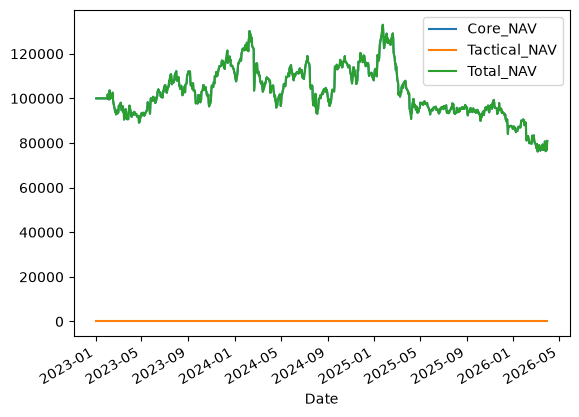

In [28]:
df_nav_effect.plot()

In [106]:
df_prices=universe_data['price']

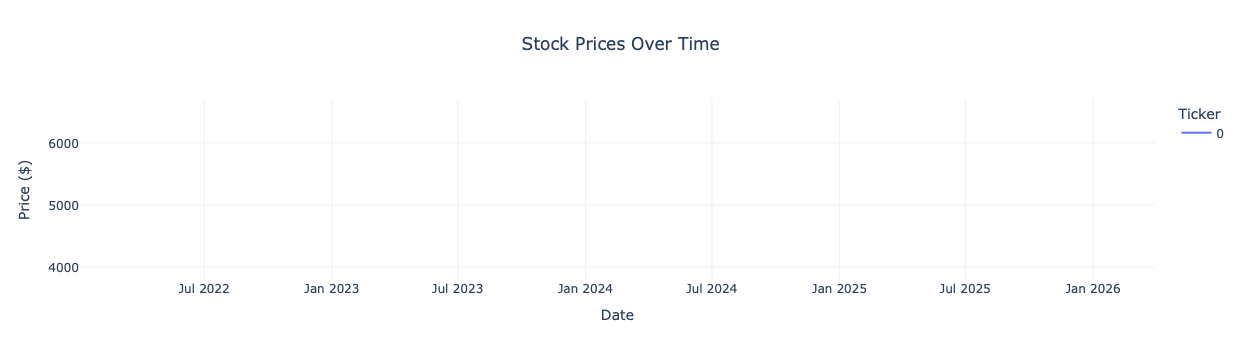

In [107]:
stock_plots.plot_ticker_prices(df_prices.sum(axis=1))

In [96]:
snapshot['price'][['QQQ']]

,QQQ
Date,
2022-01-03,390.756775
2022-01-04,385.688446
2022-01-05,373.839691
2022-01-06,373.577057
2022-01-07,369.530090
2022-01-10,369.773315
2022-01-11,375.328125
2022-01-12,376.816559
2022-01-13,367.390045


In [111]:
bench_calendar = calendar_iterator.CalendarIterator(bench_universe_data, interval="ME")
h_dict={'date':[],'h_val':[]}
for i,today in enumerate(rebalance_dates): #world_data_dict['price'].index):
    snapshot=bench_calendar.get_historical_snapshot(today)
    df_price=snapshot['price']
    if len(df_price)>150:
        h_dict['date'].append(today)
        h_dict['h_val'].append(stock_metrics.get_dfa_hurst(df_price['QQQ'],10,50))

In [112]:
pd.DataFrame.from_dict(h_dict)

,date,h_val
0,2022-08-31,0.494865
1,2022-09-30,0.507769
2,2022-10-31,0.483984
3,2022-11-30,0.460526
4,2022-12-30,0.471984
5,2023-01-31,0.493617
6,2023-02-28,0.500928
7,2023-03-31,0.508023
8,2023-04-28,0.511385
9,2023-05-31,0.500769


In [105]:
from src import stock_metrics, stock_plots

In [108]:
reload(stock_metrics)

<module 'src.stock_metrics' from '/Users/zhigangyu/Documents/Project Z/src/stock_metrics.py'>

In [102]:
df_price

AttributeError: 'dict' object has no attribute 'shape'

/Users/zhigangyu/Documents/Project Z/src/stock_metrics.py:77: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(np.log(valid_lags), np.log(rs_values), 1)


# evaluateion on bootstrap results

In [23]:
from src import stat_test

In [24]:
def nav_all(nav_list,col='Total_NAV'):
    nav_all=pd.concat([nav[col] for nav in nav_list],axis=1)
    nav_all.columns=range(0,len(nav_list))
    return nav_all

In [25]:
risk_nav_all=nav_all(risk_navs)
risk_nav_metrics=metrics.calculate_metrics(risk_nav_all)

In [26]:
info_nav_all=nav_all(info_navs)
info_nav_metrics=metrics.calculate_metrics(info_nav_all)

In [27]:
risk_nav_metrics.columns

Index(['CAGR', 'Sharpe_Ratio', 'Sortino_Ratio', 'Max_Drawdown',
       'Calmar_Ratio'],
      dtype='str')

In [40]:
for column in risk_nav_metrics.columns:
    print(f'----{column}----')
    s1,s2=risk_nav_metrics[column],info_nav_metrics[column]
    # test_res=stat_test.test_paired_series_non_parametric(s1,s2)
    test_res=stat_test.automated_paired_test(s1,s2)
    if not test_res['significant_at_5pct']:
        print(f'different: {s1.mean()} ..vs.. {s2.mean()}')
    else:
        print(f'same: {s1.mean()} ..vs.. {s2.mean()}')

----CAGR----
same: 0.1799114853780623 ..vs.. 0.1924236832228953
----Sharpe_Ratio----
same: 0.7392562372772251 ..vs.. 0.6993231332027183
----Sortino_Ratio----
same: 1.876469755704342 ..vs.. 1.8034742959731789
----Max_Drawdown----
same: 0.2614017594246385 ..vs.. 0.29531564838493124
----Calmar_Ratio----
same: 0.9910205376658745 ..vs.. 0.9232063324783212


array([[<Axes: title={'center': 'CAGR'}>]], dtype=object)

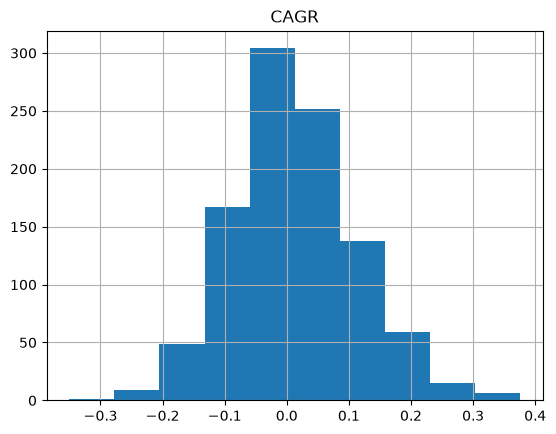

In [39]:
(info_nav_metrics[['CAGR']]-risk_nav_metrics[['CAGR']]).hist()

# benchmark

In [30]:
engine_bench,prices_3d,volume_3d=run2.get_bootstrap_words(bench_universe_data,NUM_SIMULATIONS)

In [31]:
# Run the Macro Orchestrator validation pass
spy_navs=[]
qqq_navs=[]

for sim_id in tqdm(range(NUM_SIMULATIONS)):
    # Pack the 3D slices into clean 2D DataFrames with the ORIGINAL calendar dates index
    # world_data_dict = {
    #     'price': pd.DataFrame(prices_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers),
    #     'volume': pd.DataFrame(volume_3d[sim_id, :, :], index=engine.dates_index, columns=engine.tickers)
    # }
    df_prices=pd.DataFrame(prices_3d[sim_id, :, :], index=engine_bench.dates_index, columns=engine_bench.tickers)
    spy_navs.append(df_prices[['SPY']])
    qqq_navs.append(df_prices[['QQQ']])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1313.10it/s]


In [32]:
assert len(spy_navs)==len(qqq_navs)==NUM_SIMULATIONS

In [33]:
spy_nav_all=nav_all(spy_navs,'SPY')
qqq_nav_all=nav_all(qqq_navs,'QQQ')

In [34]:
sqy_nav_metrics=metrics.calculate_metrics(spy_nav_all)
qqq_nav_metrics=metrics.calculate_metrics(qqq_nav_all)

In [35]:
for column in sqy_nav_metrics.columns:
    print(f'----{column}----')
    s1,s2=sqy_nav_metrics[column],qqq_nav_metrics[column]
    test_res=stat_test.test_paired_series_non_parametric(s1,s2)
    if not test_res['significant_at_5pct']:
        print(f'different: {s1.mean()} ..vs.. {s2.mean()}')
    else:
        print(f'same: {s1.mean()} ..vs.. {s2.mean()}')

----CAGR----
same: 0.09446482332172962 ..vs.. 0.10137824440424797
----Sharpe_Ratio----
same: 0.7289833702412534 ..vs.. 0.6374972764882084
----Sortino_Ratio----
same: 1.220004877043697 ..vs.. 1.0713361812131421
----Max_Drawdown----
same: 0.25675941436112626 ..vs.. 0.34280337500446895
----Calmar_Ratio----
same: 0.46998721726869935 ..vs.. 0.39476742605700077
